# Project 1 — Algorithm Selection (Social Golfer Problem)


1. Verify instance set size (≥ 100)  
2. Verify the **original Social Golfer family** is included: **32 golfers, 8 groups (size 4), weeks 6..10**  
3. Ensure the dataset contains those rows  
4. Train an ML selector with a **65% / 35% split**  
5. Report **accuracy + confusion matrix**  
6. Compare **Exact vs SA vs ML Selector** on runtime + finish rate



## 0) Environment setup (imports + repo path)

If imports fail (e.g., `meta_heuristics` not found), this cell adds the repo root to `sys.path` so local packages can be imported. -Kaan

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Repo root:", REPO_ROOT)


Repo root: c:\Users\kaann\Desktop\TU Wien\Machine Learning for Optimization\MLOpt\algorithmic-selection


## 1) Load CSVs

We load:
- `SGP_test_instances.csv`: list of instances (num_golfers, num_weeks, num_groups)
- `SGP_dataset.csv`: features + runtimes + labels (winner)

In [2]:
import pandas as pd
import numpy as np

INSTANCES_CSV = REPO_ROOT / "SGP_test_instances.csv"
DATASET_CSV   = REPO_ROOT / "SGP_dataset.csv"

assert INSTANCES_CSV.exists(), f"Missing {INSTANCES_CSV}"
assert DATASET_CSV.exists(), f"Missing {DATASET_CSV}"

df_i = pd.read_csv(INSTANCES_CSV)
df_d = pd.read_csv(DATASET_CSV)

print("Instances:", len(df_i))
print("Dataset rows:", len(df_d))
print("Dataset columns:", list(df_d.columns))


Instances: 206
Dataset rows: 206
Dataset columns: ['num_golfers', 'num_weeks', 'num_groups', 'group_size', 'tightness_T', 'probe_conflicts', 'sa_runtime', 'exact_runtime', 'sa_finished', 'exact_finished', 'winner']


## 2) Patch instances to include the required original family (32 golfers, 8 groups, weeks 6..10)

If these instances are missing, we append them to `SGP_test_instances.csv` (without touching other instances). -Kaan

In [3]:
key_cols = ["num_golfers", "num_weeks", "num_groups"]

required_rows = pd.DataFrame(
    [{"num_golfers": 32, "num_weeks": w, "num_groups": 8} for w in range(6, 11)]
)

existing_keys = set(map(tuple, df_i[key_cols].to_numpy()))
missing_required = [tuple(r) for r in required_rows[key_cols].to_numpy() if tuple(r) not in existing_keys]

print("Missing required original-family rows:", missing_required)

if missing_required:
    # Because the original family is mandatory, we append + de-duplicate -Kaan
    df_i = pd.concat([df_i, required_rows], ignore_index=True).drop_duplicates(subset=key_cols)
    df_i.to_csv(INSTANCES_CSV, index=False)
    print(f"Patched {INSTANCES_CSV.name}: now {len(df_i)} instances")
else:
    print("OK: original family already present in instances CSV.")


Missing required original-family rows: []
OK: original family already present in instances CSV.


## 3) Check dataset coverage for those required instances

If `SGP_dataset.csv` does not contain these rows, we can **compute only the missing required rows** inside this notebook
(using your existing Exact + SA solvers) and append them to the dataset. -Kaan

If this cell fails due to missing packages (e.g., OR-Tools), install them in your environment and rerun:
- `pip install ortools` -Kaan

In [4]:
# Find which required rows are missing from the dataset -Kaan
df_req = required_rows.copy()
df_req_keys = df_req[key_cols].drop_duplicates()
df_d_keys = df_d[key_cols].drop_duplicates()

missing_in_dataset = df_req_keys.merge(df_d_keys, on=key_cols, how="left", indicator=True)
missing_in_dataset = missing_in_dataset[missing_in_dataset["_merge"] == "left_only"][key_cols]

print("Required rows missing in dataset:", len(missing_in_dataset))
display(missing_in_dataset)


Required rows missing in dataset: 0


,num_golfers,num_weeks,num_groups


## 4) (Auto-fix) Generate missing required dataset rows inside the notebook

This runs:
- Exact CP-SAT solver (`solve_social_golfer`) with time limit
- SA solver with time limit (in a separate process)

Then it computes:
- group_size
- tightness_T
- probe_conflicts (short exact probing run)
- runtimes, finished flags
- winner label

If **no required rows are missing**, you can skip this cell. -Kaan

In [5]:
# --- Cell 4: Robust paths + ensure required instances + (optional) generate missing dataset rows ---

import time
import multiprocessing as mp
from pathlib import Path
import sys
import pandas as pd

# -------------------------
# Robust repo-root detection
# -------------------------

cwd = Path.cwd()

candidates = [cwd]
if cwd.name in {"algorithmic-selection", "algorithmic_selection"}:
    candidates.insert(0, cwd.parent)

def find_repo_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "pyproject.toml").exists():
            return p
        if (p / "constraint_programming").exists() and (p / "meta_heuristics").exists():
            return p
    return start

candidates.append(find_repo_root(cwd))

REPO_ROOT = None
for c in candidates:
    if (c / "constraint_programming").exists() and (c / "meta_heuristics").exists():
        REPO_ROOT = c
        break

if REPO_ROOT is None:
    REPO_ROOT = find_repo_root(cwd)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Detected REPO_ROOT:", REPO_ROOT)
print("sys.path[0]:", sys.path[0])
print("Has constraint_programming:", (REPO_ROOT / "constraint_programming").exists())
print("Has meta_heuristics:", (REPO_ROOT / "meta_heuristics").exists())

# -------------------------------------
# Locate CSVs (repo root vs subfolder)
# -------------------------------------

def locate_csv(name: str) -> Path:
    search_roots = [
        Path.cwd(),
        REPO_ROOT,
        REPO_ROOT / "algorithmic-selection",
        REPO_ROOT / "algorithmic_selection",
    ]
    for base in search_roots:
        p = base / name
        if p.exists():
            return p
    for base in [REPO_ROOT, Path.cwd()]:
        for p in base.glob(f"**/{name}"):
            return p
    raise FileNotFoundError(f"Could not locate required file: {name}. Searched: {[str(x) for x in search_roots]}")

DATASET_CSV = locate_csv("SGP_dataset.csv")
TEST_INSTANCES_CSV = locate_csv("SGP_test_instances.csv")

print("Using DATASET_CSV:", DATASET_CSV)
print("Using TEST_INSTANCES_CSV:", TEST_INSTANCES_CSV)

# -------------------------------------
# Ensure required original family exists
# -------------------------------------

REQUIRED_FAMILY = [
    {"num_golfers": 32, "num_groups": 8, "num_weeks": w} for w in range(6, 11)
]

if "key_cols" not in globals():
    key_cols = ["num_golfers", "num_weeks", "num_groups"]

df_test = pd.read_csv(TEST_INSTANCES_CSV)

req_df = pd.DataFrame(REQUIRED_FAMILY)[key_cols]
have_df = df_test[key_cols].drop_duplicates()

missing_required = req_df.merge(have_df, on=key_cols, how="left", indicator=True)
missing_required = missing_required[missing_required["_merge"] == "left_only"][key_cols]

if len(missing_required) > 0:
    print(f"Appending {len(missing_required)} missing required instances into {TEST_INSTANCES_CSV.name} ...")
    df_test = pd.concat([df_test, missing_required], ignore_index=True)
    df_test = df_test.drop_duplicates(subset=key_cols, keep="last")
    df_test.to_csv(TEST_INSTANCES_CSV, index=False)
else:
    print("Required original family already present in test instances.")

# -------------------------------------
# Compute which dataset rows are missing
# -------------------------------------

df_d = pd.read_csv(DATASET_CSV)

dataset_keys = df_d[key_cols].drop_duplicates()
required_keys = pd.read_csv(TEST_INSTANCES_CSV)[key_cols].drop_duplicates()

missing_in_dataset = required_keys.merge(dataset_keys, on=key_cols, how="left", indicator=True)
missing_in_dataset = missing_in_dataset[missing_in_dataset["_merge"] == "left_only"][key_cols]

print(f"Dataset rows: {len(df_d)}")
print(f"Required instance keys: {len(required_keys)}")
print(f"Missing required rows in dataset: {len(missing_in_dataset)}")

# -------------------------------------
# Optional: (Re)generate missing rows
# -------------------------------------

ENABLE_GENERATION = False

DEFAULT_TIME_LIMIT = 600.0
SA_TIME_LIMIT = float(globals().get("SA_TIME_LIMIT", DEFAULT_TIME_LIMIT))
EXACT_TIME_LIMIT = float(globals().get("EXACT_TIME_LIMIT", DEFAULT_TIME_LIMIT))
PROBE_TIME = float(globals().get("PROBE_TIME", 0.5))

print("SA_TIME_LIMIT:", SA_TIME_LIMIT)
print("EXACT_TIME_LIMIT:", EXACT_TIME_LIMIT)
print("PROBE_TIME:", PROBE_TIME)

FORCE_REEVALUATE = False
FORCE_KEYS = [{"num_golfers": 32, "num_groups": 8, "num_weeks": w} for w in range(6, 11)]

if FORCE_REEVALUATE:
    fk = pd.DataFrame(FORCE_KEYS)[key_cols]
    before = len(df_d)
    df_d = df_d.merge(fk, on=key_cols, how="left", indicator=True)
    df_d = df_d[df_d["_merge"] == "left_only"].drop(columns=["_merge"])
    df_d.to_csv(DATASET_CSV, index=False)
    print(f"Forced drop of {before - len(df_d)} rows to re-evaluate later.")
    dataset_keys = df_d[key_cols].drop_duplicates()
    missing_in_dataset = required_keys.merge(dataset_keys, on=key_cols, how="left", indicator=True)
    missing_in_dataset = missing_in_dataset[missing_in_dataset["_merge"] == "left_only"][key_cols]
    print(f"Missing required rows in dataset (after force drop): {len(missing_in_dataset)}")

if not ENABLE_GENERATION:
    print("ENABLE_GENERATION=False -> skipping solver runs.")
else:
    try:
        from constraint_programming.exact_method import solve_social_golfer
        from meta_heuristics.simulated_annealing import SimulatedAnnealing
        from meta_heuristics.problem_instance import ProblemInstance
        from meta_heuristics.solution_instance import SolutionInstance
        from meta_heuristics.swap_2_player import Swap2Player
    except ModuleNotFoundError as e:
        raise RuntimeError(
            "Failed to import project solvers.\n"
            f"Original error: {e}"
        )

    def compute_probe_conflicts(num_golfers: int, num_weeks: int, num_groups: int, probe_time: float = PROBE_TIME) -> float:
        solver = solve_social_golfer(
            num_golfers=num_golfers,
            num_groups=num_groups,
            num_weeks=num_weeks,
            return_solver=True,
            max_time=probe_time,
            logging=False,
        )
        return float(solver.NumConflicts())

    def _sa_worker(num_golfers, num_weeks, num_groups, q):
        start = time.time()
        try:
            problem = ProblemInstance(num_groups, num_golfers, num_weeks)
            neighborhood = Swap2Player()
            solution = SolutionInstance(problem, SolutionInstance.generate_random_solution, neighborhood)
            sa_solver = SimulatedAnnealing(
                solution_inst=solution,
                init_temperature=1000.0,
                final_temperature=0.01,
                equilibrium_iterations=20,
                alpha=0.90,
            )
            best_solution = sa_solver.solve()
            runtime = time.time() - start
            violations = int(best_solution.count_violations())
            q.put(("ok", runtime, violations))
        except Exception as e:
            runtime = time.time() - start
            q.put(("err", runtime, repr(e)))

    def run_sa_with_timeout(num_golfers, num_weeks, num_groups, time_limit=SA_TIME_LIMIT):
        q = mp.Queue()
        p = mp.Process(target=_sa_worker, args=(num_golfers, num_weeks, num_groups, q))
        p.start()
        p.join(timeout=time_limit)
        if p.is_alive():
            p.terminate()
            p.join()
            return False, float(time_limit), "timeout"

        try:
            tag, runtime, extra = q.get_nowait()
        except Exception:
            return False, float(time_limit), "no_result"

        if tag == "ok":
            violations = int(extra)
            return (violations == 0), float(runtime), f"violations={violations}"
        else:
            return False, float(runtime), f"error={extra}"

    def _exact_worker(num_golfers, num_weeks, num_groups, time_limit, q):
        start = time.time()
        try:
            res = solve_social_golfer(
                num_golfers=num_golfers,
                num_groups=num_groups,
                num_weeks=num_weeks,
                max_time=time_limit,
                logging=False,
            )
            runtime = time.time() - start
            if res is None:
                q.put(("err", runtime, "no_solution_or_unknown"))
            else:
                q.put(("ok", runtime, "feasible"))
        except Exception as e:
            runtime = time.time() - start
            q.put(("err", runtime, repr(e)))

    def run_exact_with_timeout(num_golfers, num_weeks, num_groups, time_limit=EXACT_TIME_LIMIT):
        q = mp.Queue()
        p = mp.Process(target=_exact_worker, args=(num_golfers, num_weeks, num_groups, time_limit, q))
        p.start()
        p.join(timeout=time_limit)
        if p.is_alive():
            p.terminate()
            p.join()
            return False, float(time_limit), "timeout"

        try:
            tag, runtime, info = q.get_nowait()
        except Exception:
            return False, float(time_limit), "no_result"

        return (tag == "ok"), float(runtime), str(info)

    def decide_winner(sa_finished, sa_runtime, exact_finished, exact_runtime):
        eps = 1e-6
        if not sa_finished and not exact_finished:
            return "none"
        if sa_finished and not exact_finished:
            return "sa"
        if exact_finished and not sa_finished:
            return "exact"
        if abs(sa_runtime - exact_runtime) <= eps:
            return "both"
        return "sa" if sa_runtime < exact_runtime else "exact"

    if len(missing_in_dataset) == 0:
        print("Nothing to generate: required rows already exist in dataset.")
    else:
        new_rows = []
        for _, r in missing_in_dataset.iterrows():
            num_golfers = int(r["num_golfers"])
            num_weeks = int(r["num_weeks"])
            num_groups = int(r["num_groups"])

            group_size = num_golfers // num_groups
            tightness_T = (num_weeks * (group_size - 1)) / (num_golfers - 1)

            try:
                probe_conflicts = compute_probe_conflicts(num_golfers, num_weeks, num_groups)
            except Exception:
                probe_conflicts = 0.0

            sa_ok, sa_runtime, sa_info = run_sa_with_timeout(num_golfers, num_weeks, num_groups)
            exact_ok, exact_runtime, exact_info = run_exact_with_timeout(num_golfers, num_weeks, num_groups)

            winner = decide_winner(sa_ok, sa_runtime, exact_ok, exact_runtime)

            row = {
                "num_golfers": num_golfers,
                "num_weeks": num_weeks,
                "num_groups": num_groups,
                "group_size": group_size,
                "tightness_T": tightness_T,
                "probe_conflicts": probe_conflicts,
                "sa_runtime": sa_runtime,
                "exact_runtime": exact_runtime,
                "sa_finished": int(sa_ok),
                "exact_finished": int(exact_ok),
                "winner": winner,
                "sa_info": sa_info,
                "exact_info": exact_info,
            }
            new_rows.append(row)
            print("Generated row:", row)

        df_new = pd.DataFrame(new_rows)
        df_d = pd.concat([df_d, df_new], ignore_index=True)

        df_d = df_d.drop_duplicates(subset=key_cols, keep="last")
        df_d.to_csv(DATASET_CSV, index=False)

        print(f"Appended {len(df_new)} rows to {DATASET_CSV.name}. New dataset size: {len(df_d)}")


Detected REPO_ROOT: c:\Users\kaann\Desktop\TU Wien\Machine Learning for Optimization\MLOpt
sys.path[0]: c:\Users\kaann\Desktop\TU Wien\Machine Learning for Optimization\MLOpt
Has constraint_programming: True
Has meta_heuristics: True
Using DATASET_CSV: c:\Users\kaann\Desktop\TU Wien\Machine Learning for Optimization\MLOpt\algorithmic-selection\SGP_dataset.csv
Using TEST_INSTANCES_CSV: c:\Users\kaann\Desktop\TU Wien\Machine Learning for Optimization\MLOpt\algorithmic-selection\SGP_test_instances.csv
Required original family already present in test instances.
Dataset rows: 206
Required instance keys: 206
Missing required rows in dataset: 0
SA_TIME_LIMIT: 600.0
EXACT_TIME_LIMIT: 600.0
PROBE_TIME: 0.5
ENABLE_GENERATION=False -> skipping solver runs.


## 5) Train ML selector (65% train / 35% test)

We use ≥5 features and predict the `winner` label.

- Features: `num_golfers`, `num_weeks`, `group_size`, `tightness_T`, `probe_conflicts`
- Target: `winner`

We exclude `winner == "none"` during training because it means both solvers failed. -Kaan

Python: 3.8.10 (tags/v3.8.10:3d8993a, May  3 2021, 11:48:03) [MSC v.1928 64 bit (AMD64)]
NumPy: 1.24.4

Accuracy: 0.9272727272727272

Classification report:
               precision    recall  f1-score   support

       exact       0.94      0.83      0.88        18
          sa       0.92      0.97      0.95        37

    accuracy                           0.93        55
   macro avg       0.93      0.90      0.91        55
weighted avg       0.93      0.93      0.93        55



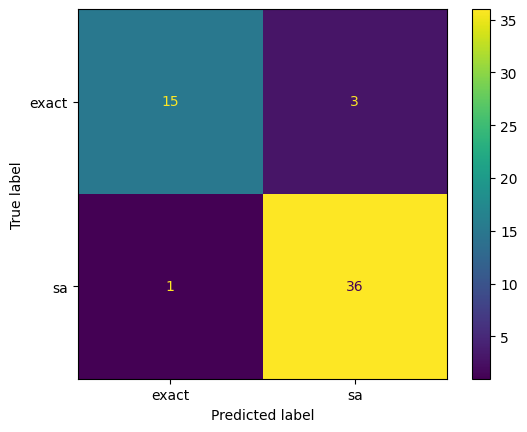

In [6]:
# --- Cell 5: ML training (defines `clf` for later cells) ---

import sys
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("NumPy:", np.__version__)

# Because later cells rely on df_d, we load it here if it doesn't exist yet -Kaan
if "df_d" not in globals():
    DATASET_CSV = Path("SGP_dataset.csv")
    if not DATASET_CSV.exists():
        raise FileNotFoundError("SGP_dataset.csv not found next to the notebook. -Kaan")
    df_d = pd.read_csv(DATASET_CSV)
    print(f"Loaded df_d from {DATASET_CSV.name} (rows={len(df_d)}) -Kaan")

# Because the selector must use >=5 features, we train on these 5 columns -Kaan
FEATURES = ["num_golfers", "num_weeks", "group_size", "tightness_T", "probe_conflicts"]

missing_cols = [c for c in FEATURES + ["winner"] if c not in df_d.columns]
if missing_cols:
    raise ValueError(f"Dataset is missing required columns: {missing_cols} -Kaan")

# Because 'none' means both failed (no clear best method), we exclude it from supervised learning -Kaan
df_train = df_d[df_d["winner"] != "none"].copy()

# Because 'both' is ambiguous, we map it to 'sa' (either is fine, but SA is acceptable default) -Kaan
df_train["winner"] = df_train["winner"].replace({"both": "sa"})

X = df_train[FEATURES]
y = df_train["winner"]

# Because stratify can fail when a class has too few samples, we try stratify then fall back -Kaan
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.35, random_state=42, stratify=y
    )
except ValueError as e:
    print("Stratify failed, falling back to non-stratified split. -Kaan")
    print("Reason:", e)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.35, random_state=42
    )

# Because Random Forest is a strong baseline for algorithm selection classification, we use it here -Kaan
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.show()


## 6) Compare Exact vs SA vs ML AlgorithmSelector

We compute:
- average runtime
- finish rate (fraction of instances where a method finished within time)

AlgorithmSelector chooses the method predicted by ML and uses that method’s runtime/finished flag. -Kaan

In [7]:
from pathlib import Path
import pandas as pd
import numpy as np

if "df_d" not in globals():
    DATASET_CSV = Path("SGP_dataset.csv")
    df_d = pd.read_csv(DATASET_CSV)
    print(f"Reloaded df_d from {DATASET_CSV} (rows={len(df_d)}) -Kaan")

# Because Cell 6 depends on a trained model, we ensure clf exists and fail fast otherwise -Kaan
if "clf" not in globals():
    raise RuntimeError("Model 'clf' is not defined. Run Cell 5 (training) before Cell 6. -Kaan")

# Keep features consistent with the training cell -Kaan
FEATURES = ["num_golfers", "num_weeks", "group_size", "tightness_T", "probe_conflicts"]

needed_cols = set(FEATURES + ["winner", "sa_runtime", "exact_runtime", "sa_finished", "exact_finished"])
missing = needed_cols - set(df_d.columns)
if missing:
    raise ValueError(f"Dataset is missing required columns: {sorted(missing)} -Kaan")

df_all = df_d.copy()

# Predict for every instance using the trained selector -Kaan
df_all["predicted_winner"] = clf.predict(df_all[FEATURES])

# Because 'both' means both solved fast, choosing SA is acceptable for a simple selector baseline -Kaan
def selector_choice(row):
    pred = row["predicted_winner"]
    if pred == "exact":
        return "exact"
    # for 'sa' OR 'both' OR anything else, default to SA -Kaan
    return "sa"

def selector_runtime(row):
    if selector_choice(row) == "exact":
        return float(row["exact_runtime"])
    return float(row["sa_runtime"])

def selector_finished(row):
    if selector_choice(row) == "exact":
        return bool(int(row["exact_finished"]))
    return bool(int(row["sa_finished"]))

df_all["selector_choice"] = df_all.apply(selector_choice, axis=1)
df_all["selector_runtime"] = df_all.apply(selector_runtime, axis=1)
df_all["selector_finished"] = df_all.apply(selector_finished, axis=1)

summary = pd.DataFrame({
    "method": ["Exact", "SA", "AlgorithmSelector"],
    "avg_runtime": [
        df_all["exact_runtime"].mean(),
        df_all["sa_runtime"].mean(),
        df_all["selector_runtime"].mean(),
    ],
    "finish_rate": [
        df_all["exact_finished"].mean(),
        df_all["sa_finished"].mean(),
        df_all["selector_finished"].mean(),
    ],
})

summary


,method,avg_runtime,finish_rate
0,Exact,25.087717,0.762136
1,SA,35.670456,0.645631
2,AlgorithmSelector,24.406959,0.762136


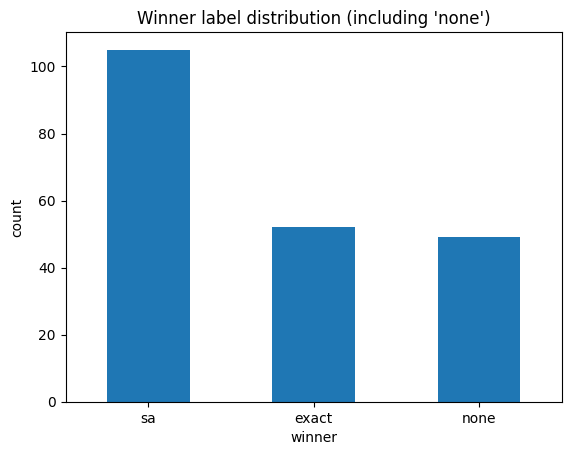

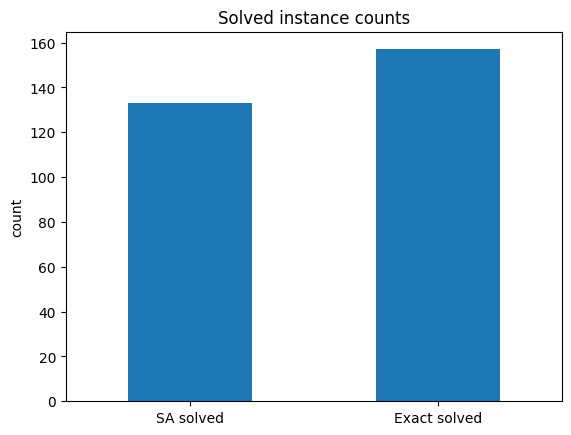

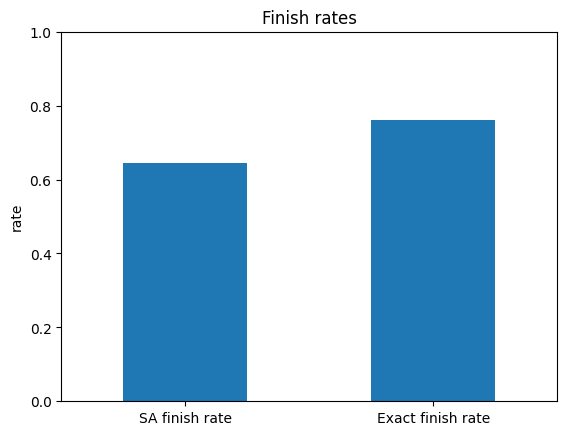

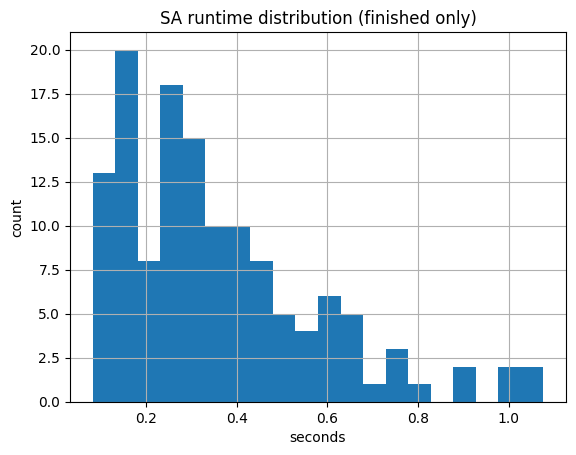

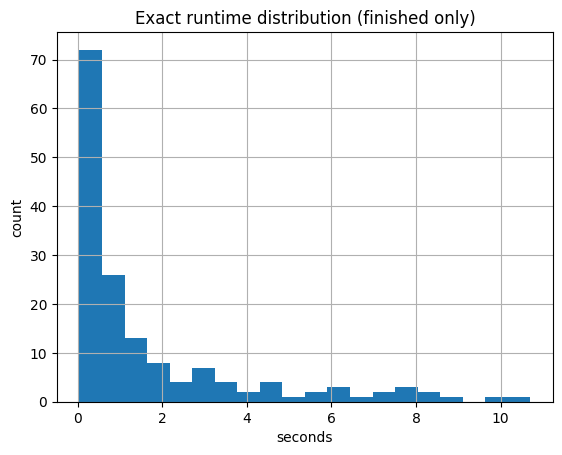

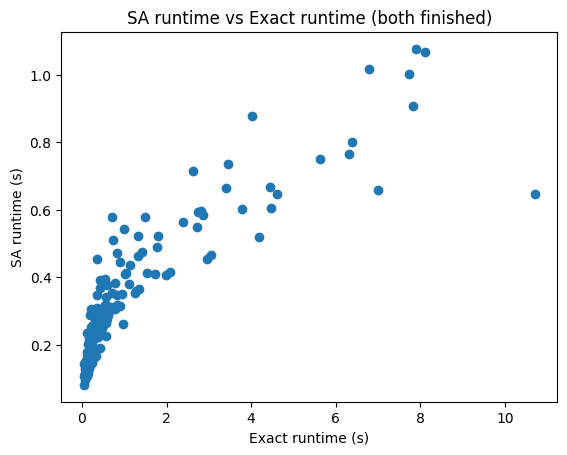

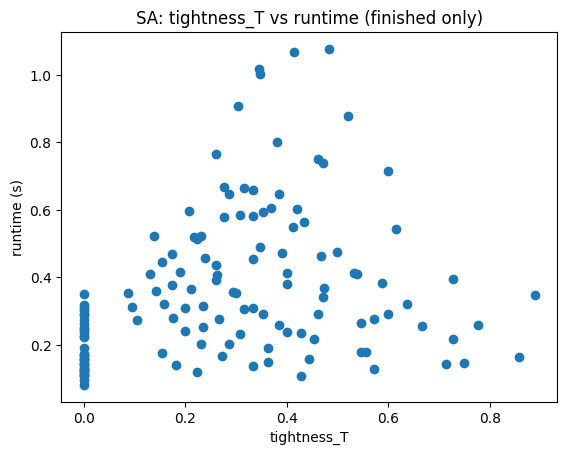

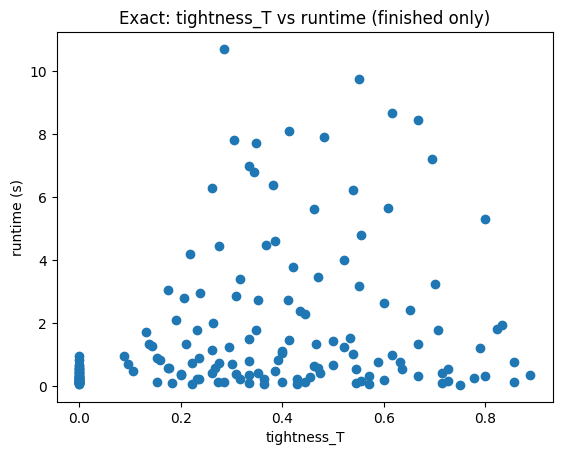

Original family (table):


,num_weeks,tightness_T,probe_conflicts,sa_runtime,exact_runtime,sa_finished,exact_finished,winner
201,6,0.580645,0.0,100.0,100.0,0,0,none
202,7,0.677419,0.0,100.0,100.0,0,0,none
203,8,0.774194,0.0,100.0,100.0,0,0,none
204,9,0.870968,0.0,100.0,100.0,0,0,none
205,10,0.967742,0.0,100.0,100.0,0,0,none


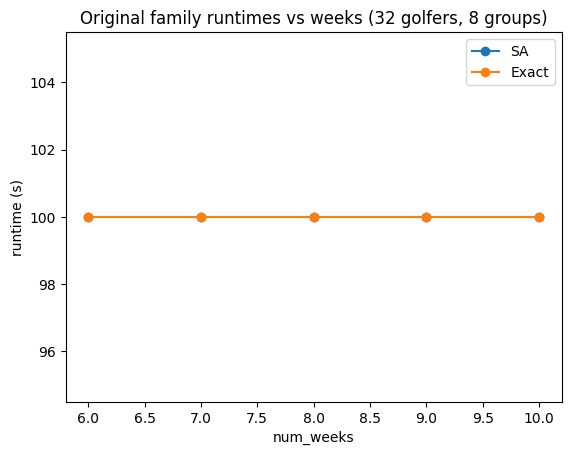

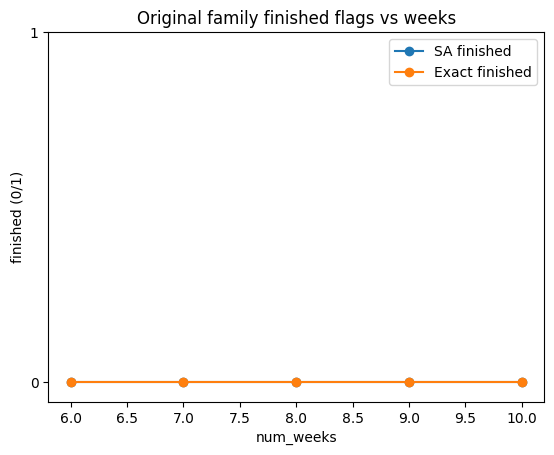

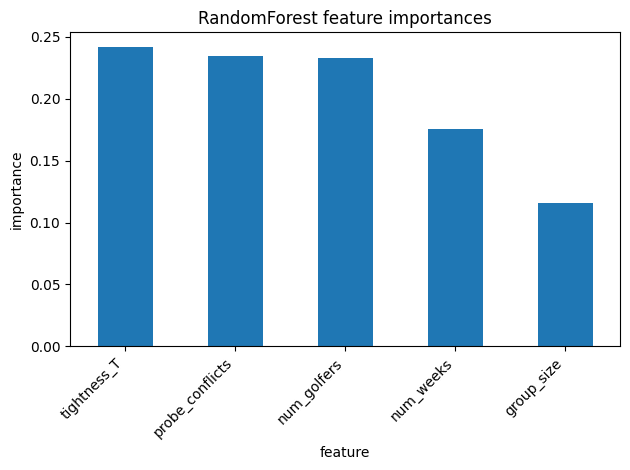

In [8]:
# --- Visualization Cell ---

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

if "DATASET_CSV" in globals():
    _dataset_path = Path(DATASET_CSV)
else:
    _dataset_path = Path("SGP_dataset.csv") 

df_viz = pd.read_csv(_dataset_path)

# 1) Winner label distribution
plt.figure()
df_viz["winner"].value_counts(dropna=False).plot(kind="bar")
plt.title("Winner label distribution (including 'none')")
plt.xlabel("winner")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.show()

# 2) Solved counts + finish rates
sa_finished = df_viz.get("sa_finished", pd.Series([0]*len(df_viz))).astype(int)
exact_finished = df_viz.get("exact_finished", pd.Series([0]*len(df_viz))).astype(int)

plt.figure()
pd.Series({"SA solved": sa_finished.sum(), "Exact solved": exact_finished.sum()}).plot(kind="bar")
plt.title("Solved instance counts")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.show()

plt.figure()
pd.Series({"SA finish rate": sa_finished.mean(), "Exact finish rate": exact_finished.mean()}).plot(kind="bar")
plt.title("Finish rates")
plt.ylabel("rate")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

# 3) Runtime distributions (only finished)
if "sa_runtime" in df_viz.columns:
    plt.figure()
    df_viz.loc[sa_finished == 1, "sa_runtime"].hist(bins=20)
    plt.title("SA runtime distribution (finished only)")
    plt.xlabel("seconds")
    plt.ylabel("count")
    plt.show()

if "exact_runtime" in df_viz.columns:
    plt.figure()
    df_viz.loc[exact_finished == 1, "exact_runtime"].hist(bins=20)
    plt.title("Exact runtime distribution (finished only)")
    plt.xlabel("seconds")
    plt.ylabel("count")
    plt.show()

# 4) Where is SA faster vs Exact? (only where BOTH finished)
if {"sa_runtime", "exact_runtime"}.issubset(df_viz.columns):
    both = df_viz[(sa_finished == 1) & (exact_finished == 1)].copy()
    if len(both) > 0:
        plt.figure()
        plt.scatter(both["exact_runtime"], both["sa_runtime"])
        plt.title("SA runtime vs Exact runtime (both finished)")
        plt.xlabel("Exact runtime (s)")
        plt.ylabel("SA runtime (s)")
        plt.show()
    else:
        print("No instances where both SA and Exact finished skipping runtime scatter. -Kaan")

# 5) Tightness vs runtime (finished only)
if {"tightness_T", "sa_runtime"}.issubset(df_viz.columns):
    tmp = df_viz[sa_finished == 1]
    plt.figure()
    plt.scatter(tmp["tightness_T"], tmp["sa_runtime"])
    plt.title("SA: tightness_T vs runtime (finished only)")
    plt.xlabel("tightness_T")
    plt.ylabel("runtime (s)")
    plt.show()

if {"tightness_T", "exact_runtime"}.issubset(df_viz.columns):
    tmp = df_viz[exact_finished == 1]
    plt.figure()
    plt.scatter(tmp["tightness_T"], tmp["exact_runtime"])
    plt.title("Exact: tightness_T vs runtime (finished only)")
    plt.xlabel("tightness_T")
    plt.ylabel("runtime (s)")
    plt.show()

# 6) Original family spotlight (32 golfers, 8 groups, weeks 6..10)
fam = df_viz[(df_viz.get("num_golfers") == 32) & (df_viz.get("num_groups") == 8) & (df_viz.get("num_weeks").between(6, 10))].copy()
if len(fam) == 0:
    print("Original family rows not found in dataset yet.")
else:
    fam = fam.sort_values("num_weeks")
    print("Original family (table):")
    display_cols = [c for c in [
        "num_weeks", "tightness_T", "probe_conflicts",
        "sa_runtime", "exact_runtime", "sa_finished", "exact_finished", "winner"
    ] if c in fam.columns]
    display(fam[display_cols])

    if {"sa_runtime", "exact_runtime"}.issubset(fam.columns):
        plt.figure()
        plt.plot(fam["num_weeks"], fam["sa_runtime"], marker="o", label="SA")
        plt.plot(fam["num_weeks"], fam["exact_runtime"], marker="o", label="Exact")
        plt.title("Original family runtimes vs weeks (32 golfers, 8 groups)")
        plt.xlabel("num_weeks")
        plt.ylabel("runtime (s)")
        plt.legend()
        plt.show()

    if {"sa_finished", "exact_finished"}.issubset(fam.columns):
        plt.figure()
        plt.plot(fam["num_weeks"], fam["sa_finished"], marker="o", label="SA finished")
        plt.plot(fam["num_weeks"], fam["exact_finished"], marker="o", label="Exact finished")
        plt.title("Original family finished flags vs weeks")
        plt.xlabel("num_weeks")
        plt.ylabel("finished (0/1)")
        plt.yticks([0, 1])
        plt.legend()
        plt.show()

# 7) Feature importance (only if clf exists from Cell 5)
if "clf" in globals() and hasattr(clf, "feature_importances_") and "FEATURES" in globals():
    plt.figure()
    imp = pd.Series(clf.feature_importances_, index=FEATURES).sort_values(ascending=False)
    imp.plot(kind="bar")
    plt.title("RandomForest feature importances")
    plt.xlabel("feature")
    plt.ylabel("importance")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 7) Focus on the original family (32 golfers, 8 groups, weeks 6..10)

This table is the key “proof” that the required original scenario family is covered and evaluated. -Kaan

In [9]:
cols = ["num_golfers","num_groups","num_weeks","group_size","tightness_T","probe_conflicts",
        "sa_runtime","exact_runtime","sa_finished","exact_finished","winner","predicted_winner"]

orig = df_all[(df_all["num_golfers"] == 32) & (df_all["num_groups"] == 8) & (df_all["num_weeks"].between(6,10))]
orig[cols].sort_values("num_weeks")


,num_golfers,num_groups,num_weeks,group_size,tightness_T,probe_conflicts,sa_runtime,exact_runtime,sa_finished,exact_finished,winner,predicted_winner
201,32,8,6,4,0.580645,0.0,100.0,100.0,0,0,none,sa
202,32,8,7,4,0.677419,0.0,100.0,100.0,0,0,none,sa
203,32,8,8,4,0.774194,0.0,100.0,100.0,0,0,none,sa
204,32,8,9,4,0.870968,0.0,100.0,100.0,0,0,none,sa
205,32,8,10,4,0.967742,0.0,100.0,100.0,0,0,none,sa


In [10]:
from pathlib import Path
import pandas as pd

REPO_ROOT = Path.cwd()  
DATASET_CSV = next(REPO_ROOT.rglob("SGP_dataset.csv"))  

df = pd.read_csv(DATASET_CSV)
print("Loaded:", DATASET_CSV)
print(df["winner"].value_counts(dropna=False))
print("\nFinished counts:")
print("SA finished:", df["sa_finished"].sum())
print("Exact finished:", df["exact_finished"].sum())
print("\nNONE ratio:", (df["winner"] == "none").mean())


Loaded: c:\Users\kaann\Desktop\TU Wien\Machine Learning for Optimization\MLOpt\algorithmic-selection\SGP_dataset.csv
winner
sa       105
exact     52
none      49
Name: count, dtype: int64

Finished counts:
SA finished: 133
Exact finished: 157

NONE ratio: 0.23786407766990292


## 8) Export tables for report/slides (optional)

Creates:
- `results_summary.csv`
- `results_original_family.csv` -Kaan

In [11]:
summary.to_csv(REPO_ROOT / "results_summary.csv", index=False)
orig[cols].sort_values("num_weeks").to_csv(REPO_ROOT / "results_original_family.csv", index=False)

print("Wrote results_summary.csv and results_original_family.csv")


Wrote results_summary.csv and results_original_family.csv
